Shape: (777600, 21)
Shape X: (100000, 15)
Shape y: (100000,)
Train shape: (622080, 15)
Test shape : (155520, 15)
Model loaded: ..\outputs\models\random_forest_fault_model.pkl
Threshold: 0.3

Confusion Matrix:
[[153362    847]
 [   291   1020]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9981    0.9945    0.9963    154209
           1     0.5463    0.7780    0.6419      1311

    accuracy                         0.9927    155520
   macro avg     0.7722    0.8863    0.8191    155520
weighted avg     0.9943    0.9927    0.9933    155520



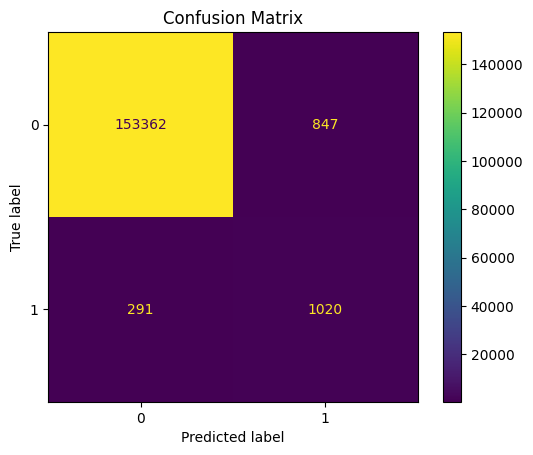

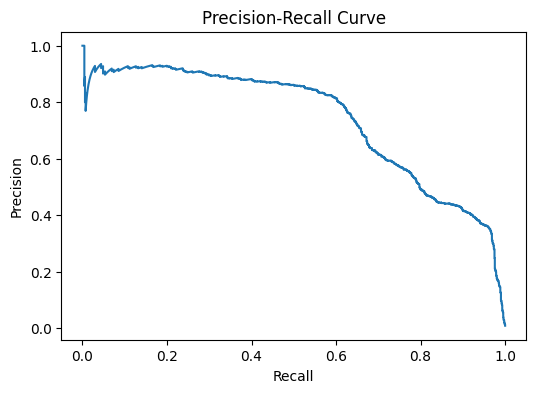

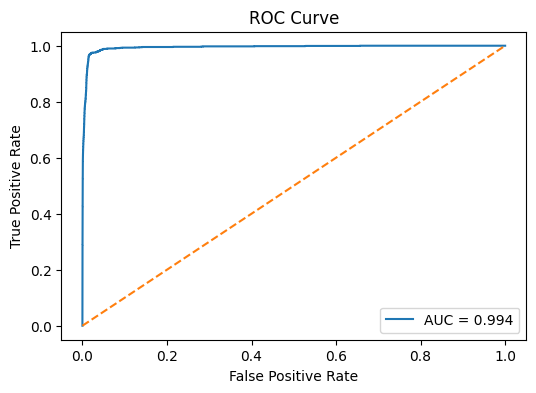

In [4]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("../data/chemical_process_timeseries.csv")
print("Shape:", df.shape)
df.head()

corr = df.corr(numeric_only=True)["time_to_fault_min"].sort_values(key=abs, ascending=False)
corr.head(15)

FEATURES = [
    "reactor_temp",
    "reactor_pressure",
    "feed_flow_rate",
    "coolant_flow_rate",
    "agitator_speed_rpm",
    "reaction_rate",
    "conversion_rate",
    "selectivity",
    "yield_pct",
    "vibration_rms",
    "motor_current",
    "power_consumption_kw",
    "temp_setpoint",
    "pressure_setpoint",
    "efficiency_loss_pct"
]

df["fault_soon"] = (
    (df["time_to_fault_min"] <= 200) &
    (df["time_to_fault_min"].notna())
).astype(int)

df["fault_soon"].value_counts()

df_model = df[FEATURES + ["fault_soon"]].copy()
df_model = df_model.ffill().bfill().dropna()
df_model = df_model.sample(n=100000, random_state=42)

X = df_model[FEATURES]
y = df_model["fault_soon"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

df_ts = df.copy()
df_ts["timestamp"] = pd.to_datetime(df_ts["timestamp"], errors="coerce")
df_ts = df_ts.sort_values("timestamp").reset_index(drop=True)

df_ts["fault_soon"] = (
    (df_ts["time_to_fault_min"] <= 200) &
    (df_ts["time_to_fault_min"].notna())
).astype(int)

df_model = df_ts[["timestamp"] + FEATURES + ["fault_soon"]].copy()
df_model = df_model.ffill().bfill().dropna()

split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

X_train = train_df[FEATURES]
y_train = train_df["fault_soon"]

X_test = test_df[FEATURES]
y_test = test_df["fault_soon"]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

model_path = Path("../outputs/models/random_forest_fault_model.pkl")
model = joblib.load(model_path)

print("Model loaded:", model_path)

y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

print("Threshold:", threshold)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

